# LearnedCache — YCSB evaluation visualizations

Renders the policy-evaluation results from `results/`:
`ycsb_eval_results.json` (classical policies + ML-protect + ML-rank 20x),
`ycsb_eval_mglru.json` (kernel MGLRU baseline) and
`ycsb_eval_ml{10,30,40}.json` (ML-rank oversampling sweep).
Per-workload matched models from `/mydata/models-jun-11` (see `ycsb_eval_meta.json`).

Setup: 240 s timed + 45 s warmup per config, 10 GiB cgroup, 8 CPUs, 1 iteration.
`ycsb_e` p99 uses SCAN p99 (READ p99 is 0 on the scan-only workload).
Figures are also written to `visualizations/figs/`.

In [1]:
import json, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm

BASE = os.path.realpath(os.path.join(os.getcwd(), '..')) if os.path.basename(os.getcwd()) == 'visualizations' else '/mydata/cache_ext_lc'
RES, FIGS = os.path.join(BASE, 'results'), os.path.join(BASE, 'visualizations', 'figs')
os.makedirs(FIGS, exist_ok=True)

plt.rcParams.update({
    'font.family': 'monospace',
    'font.monospace': ['DejaVu Sans Mono'],
    'font.size': 12,
    'axes.titlesize': 16, 'axes.labelsize': 15,
    'axes.labelweight': 'bold',
    'xtick.labelsize': 12, 'ytick.labelsize': 12,
    'legend.fontsize': 10.5, 'legend.frameon': True, 'legend.framealpha': 0.95,
    'axes.grid': True, 'grid.alpha': 0.3, 'grid.linestyle': '-',
    'figure.dpi': 110, 'savefig.dpi': 170, 'savefig.bbox': 'tight',
})

COLORS = {
    'Linux LRU':           '#8D99AE',  # slate (Linux default, MGLRU off)
    'MGLRU (Linux)':       '#FF6B35',  # bright orange
    'MRU (cache_ext)':     '#9B5DE5',  # violet
    'FIFO (cache_ext)':    '#F15BB5',  # magenta
    'S3-FIFO (cache_ext)': '#8AC926',  # lime
    'LHD (cache_ext)':     '#1982C4',  # azure
    'LFU (cache_ext)':     '#FFCA3A',  # gold
    'ML-protect (ours)':   '#00BBF9',  # sky
    'ML-rank 10x (ours)':  '#B8F2E6',  # mint
    'ML-rank 20x (ours)':  '#64DFBB',
    'ML-rank 30x (ours)':  '#00C2A8',
    'ML-rank 40x (ours)':  '#008F7A',
}
WORKLOADS = ['ycsb_a', 'ycsb_b', 'ycsb_c', 'ycsb_d', 'ycsb_e', 'ycsb_f']
WLABELS = ['YCSB\nA', 'YCSB\nB', 'YCSB\nC', 'YCSB\nD', 'YCSB\nE', 'YCSB\nF']
CLASSICAL = ['MRU (cache_ext)', 'FIFO (cache_ext)', 'S3-FIFO (cache_ext)',
             'LHD (cache_ext)', 'LFU (cache_ext)']

In [2]:
# --- load every results file into one tidy DataFrame ---
LOADER_LABEL = {
    'cache_ext_mru.out': 'MRU (cache_ext)', 'cache_ext_fifo.out': 'FIFO (cache_ext)',
    'cache_ext_s3fifo.out': 'S3-FIFO (cache_ext)', 'cache_ext_lhd.out': 'LHD (cache_ext)',
    'cache_ext_sampling.out': 'LFU (cache_ext)',
    'cache_ext_fifo_ml_protect.out': 'ML-protect (ours)',
}

def p99_ms(res, workload):
    lat = res.get('latency_p99') or 0.0
    if lat == 0.0:
        lat = res.get('scan_latency_p99') or 0.0
    return lat / 1e6

def rows_from(path, ml_label=None, baseline_label='MGLRU (Linux)'):
    if not os.path.exists(path):
        return []
    out = []
    for e in json.load(open(path)):
        cfg, res = e['config'], e['results']
        w = cfg.get('benchmark')
        if w not in WORKLOADS:
            continue
        if cfg.get('cgroup_name') == 'baseline_test':
            label = baseline_label
        else:
            loader = cfg.get('policy_loader')
            if loader == 'cache_ext_ml_sampling.out':
                label = ml_label  # ml_sampling rows live in per-factor ml<F> files
            else:
                label = LOADER_LABEL.get(loader)
        if not label:
            continue
        out.append({'workload': w, 'policy': label,
                    'tput': res.get('throughput_avg'),
                    'p99_ms': p99_ms(res, w),
                    'avg_ms': (res.get('latency_avg') or 0) / 1e6,
                    'read_p99_ms': (res.get('read_latency_p99') or 0) / 1e6,
                    'update_p99_ms': (res.get('update_latency_p99') or 0) / 1e6,
                    'scan_p99_ms': (res.get('scan_latency_p99') or 0) / 1e6})
    return out

df = pd.DataFrame(
    rows_from(os.path.join(RES, 'ycsb_eval_results.json'))
    + rows_from(os.path.join(RES, 'ycsb_eval_lru.json'), baseline_label='Linux LRU')
    + rows_from(os.path.join(RES, 'ycsb_eval_mglru.json'))
    + rows_from(os.path.join(RES, 'ycsb_eval_ml10.json'), 'ML-rank 10x (ours)')
    + rows_from(os.path.join(RES, 'ycsb_eval_ml20.json'), 'ML-rank 20x (ours)')
    + rows_from(os.path.join(RES, 'ycsb_eval_ml30.json'), 'ML-rank 30x (ours)')
    + rows_from(os.path.join(RES, 'ycsb_eval_ml40.json'), 'ML-rank 40x (ours)'))

tput = df.pivot(index='workload', columns='policy', values='tput').reindex(WORKLOADS)
p99 = df.pivot(index='workload', columns='policy', values='p99_ms').reindex(WORKLOADS)
best_classical = tput[CLASSICAL].max(axis=1)
print(f'{len(df)} rows, {df.policy.nunique()} policies x {df.workload.nunique()} workloads')
tput.round(0)

72 rows, 12 policies x 6 workloads


policy,FIFO (cache_ext),LFU (cache_ext),LHD (cache_ext),Linux LRU,MGLRU (Linux),ML-protect (ours),ML-rank 10x (ours),ML-rank 20x (ours),ML-rank 30x (ours),ML-rank 40x (ours),MRU (cache_ext),S3-FIFO (cache_ext)
workload,,,,,,,,,,,,
ycsb_a,12745.0,18190.0,17823.0,14956.0,15150.0,15355.0,16844.0,18998.0,20180.0,20502.0,6949.0,17943.0
ycsb_b,8172.0,14069.0,14207.0,10296.0,10551.0,10502.0,12635.0,14356.0,14254.0,13795.0,3493.0,12538.0
ycsb_c,7201.0,11505.0,11636.0,9091.0,9289.0,8777.0,10226.0,11654.0,11829.0,11396.0,1938.0,10497.0
ycsb_d,199346.0,206927.0,201484.0,199257.0,197590.0,155251.0,163433.0,165288.0,170073.0,173272.0,220721.0,198078.0
ycsb_e,2275.0,3878.0,3688.0,2625.0,2649.0,2988.0,3674.0,3788.0,3714.0,3585.0,1295.0,3153.0
ycsb_f,12701.0,18281.0,17840.0,14998.0,15112.0,15342.0,17106.0,19046.0,20279.0,20667.0,6849.0,18006.0


## Headline: throughput + p99 latency, grouped bars
Paper-figure layout (two panels, K-labels). ML-rank shown at its recommended
default factor (30x); the full factor sweep gets its own figures below.

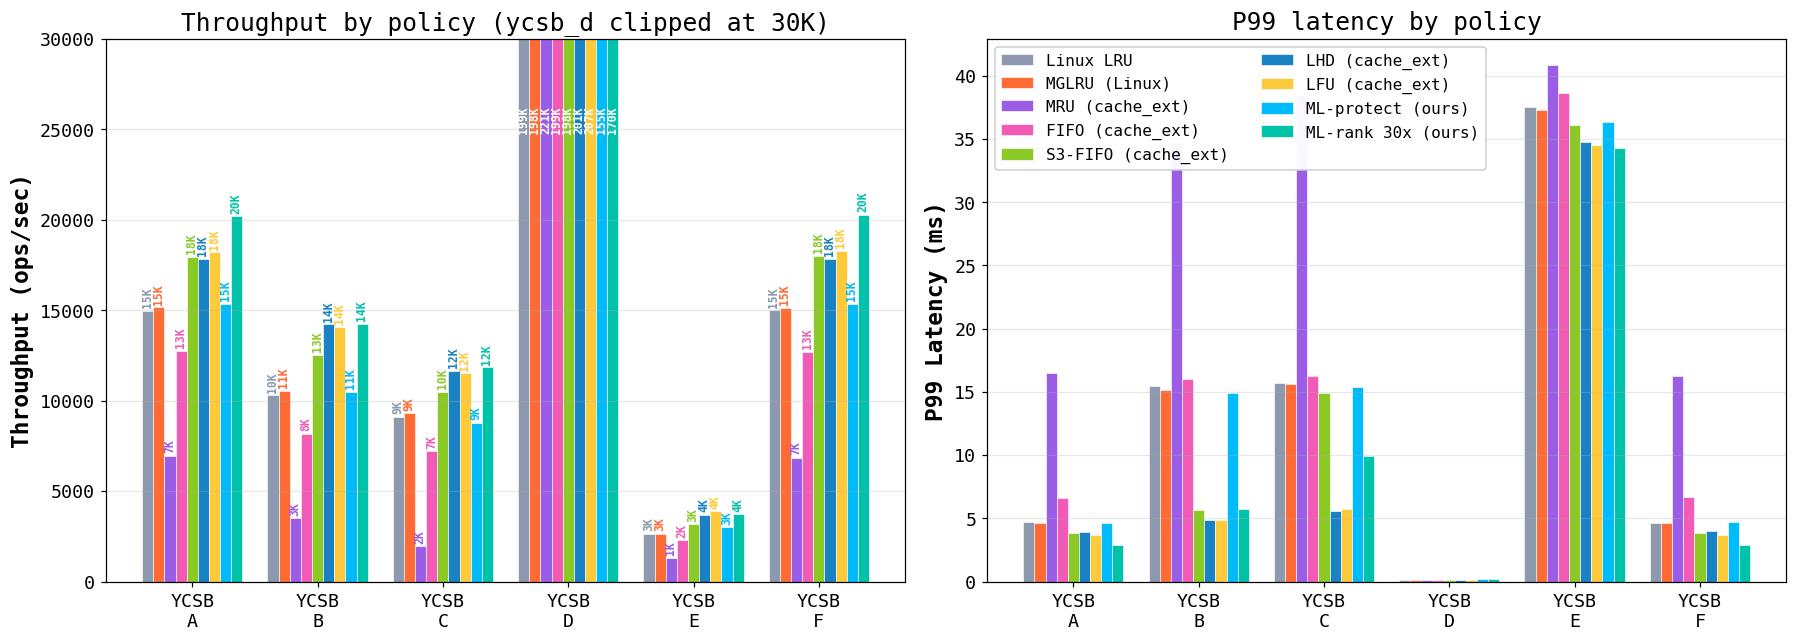

In [3]:
HEADLINE = ['Linux LRU', 'MGLRU (Linux)', 'MRU (cache_ext)', 'FIFO (cache_ext)', 'S3-FIFO (cache_ext)',
            'LHD (cache_ext)', 'LFU (cache_ext)', 'ML-protect (ours)', 'ML-rank 30x (ours)']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16.5, 6))
x = np.arange(len(WORKLOADS))
width = 0.8 / len(HEADLINE)
for i, pol in enumerate(HEADLINE):
    pos = x - 0.4 + width * (i + 0.5)
    vals = tput[pol].values
    bars = ax1.bar(pos, vals, width, label=pol, color=COLORS[pol],
                   edgecolor='white', linewidth=0.4)
    for r, v in zip(bars, vals):
        if np.isfinite(v) and v > 0:
            clipped = v > 29000
            ax1.annotate(f'{v/1000:.0f}K',
                         (r.get_x() + r.get_width()/2, 25500 if clipped else v),
                         ha='center', va='center' if clipped else 'bottom',
                         fontsize=7.5, rotation=90,
                         color='white' if clipped else COLORS[pol],
                         fontweight='bold', xytext=(0, 0 if clipped else 2),
                         textcoords='offset points')
    ax2.bar(pos, p99[pol].values, width, label=pol, color=COLORS[pol],
            edgecolor='white', linewidth=0.4)
ax1.set_ylim(0, 30000); ax1.set_ylabel('Throughput (ops/sec)')
ax2.set_ylabel('P99 Latency (ms)')
for ax in (ax1, ax2):
    ax.set_xticks(x); ax.set_xticklabels(WLABELS); ax.grid(axis='x', alpha=0)
ax1.set_title('Throughput by policy (ycsb_d clipped at 30K)')
ax2.set_title('P99 latency by policy')
ax2.legend(ncol=2)
fig.tight_layout()
fig.savefig(os.path.join(FIGS, 'fig1_throughput_p99_bars.png'))
plt.show()

## Oversampling-factor sweep
ML-rank throughput (normalized to the best classical cache_ext policy per
workload) across sample_size 10/20/30/40. Above the red line = beats every
classical policy.

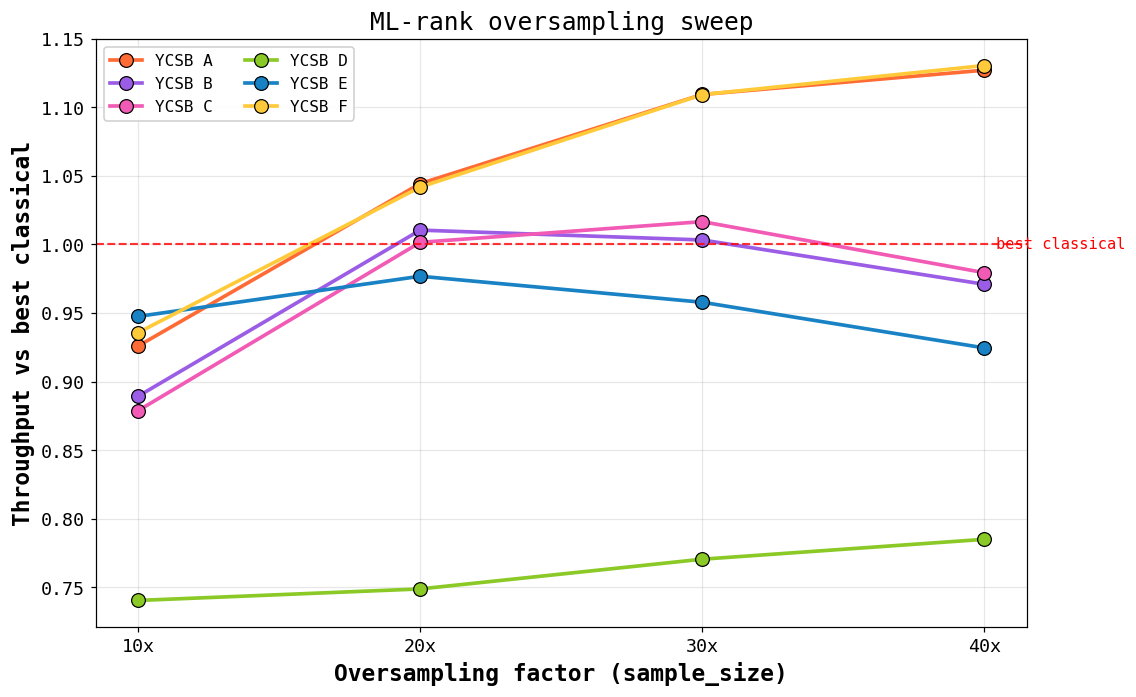

In [4]:
FACTORS = [10, 20, 30, 40]
RANK_LABELS = {f: f'ML-rank {f}x (ours)' for f in FACTORS}
wl_colors = ['#FF6B35', '#9B5DE5', '#F15BB5', '#8AC926', '#1982C4', '#FFCA3A']

fig, ax = plt.subplots(figsize=(10.5, 6.5))
for w, wl, c in zip(WORKLOADS, WLABELS, wl_colors):
    rel = [tput.loc[w, RANK_LABELS[f]] / best_classical[w] for f in FACTORS]
    ax.plot(FACTORS, rel, marker='o', markersize=9, linewidth=2.4, color=c,
            markeredgecolor='black', markeredgewidth=0.8, label=wl.replace('\n', ' '))
ax.axhline(1.0, color='red', linestyle='--', linewidth=1.4, alpha=0.8)
ax.text(40.4, 1.0, 'best classical', color='red', fontsize=10, va='center')
ax.set_xticks(FACTORS); ax.set_xticklabels([f'{f}x' for f in FACTORS])
ax.set_xlabel('Oversampling factor (sample_size)')
ax.set_ylabel('Throughput vs best classical')
ax.set_title('ML-rank oversampling sweep')
ax.legend(ncol=2)
fig.tight_layout()
fig.savefig(os.path.join(FIGS, 'fig3_oversampling_sweep.png'))
plt.show()

### Same sweep, normalized to FIFO
Both ML variants are built on top of FIFO (protect = FIFO order + model skip,
rank = FIFO list + sampled model scoring), so FIFO is the ablation base: this
is the pure value-added of the model.

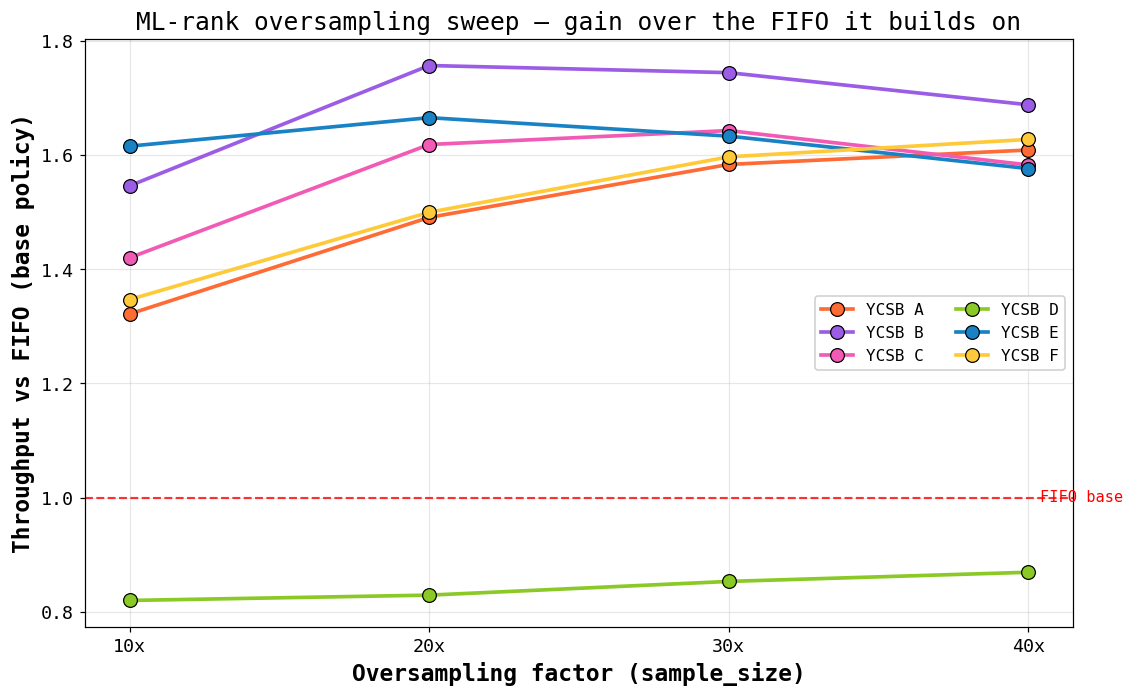

In [5]:
fifo = tput['FIFO (cache_ext)']

fig, ax = plt.subplots(figsize=(10.5, 6.5))
for w, wl, c in zip(WORKLOADS, WLABELS, wl_colors):
    rel = [tput.loc[w, RANK_LABELS[f]] / fifo[w] for f in FACTORS]
    ax.plot(FACTORS, rel, marker='o', markersize=9, linewidth=2.4, color=c,
            markeredgecolor='black', markeredgewidth=0.8, label=wl.replace('\n', ' '))
ax.axhline(1.0, color='red', linestyle='--', linewidth=1.4, alpha=0.8)
ax.text(40.4, 1.0, 'FIFO base', color='red', fontsize=10, va='center')
ax.set_xticks(FACTORS); ax.set_xticklabels([f'{f}x' for f in FACTORS])
ax.set_xlabel('Oversampling factor (sample_size)')
ax.set_ylabel('Throughput vs FIFO (base policy)')
ax.set_title('ML-rank oversampling sweep — gain over the FIFO it builds on')
ax.legend(ncol=2)
fig.tight_layout()
fig.savefig(os.path.join(FIGS, 'fig3b_oversampling_sweep_vs_fifo.png'))
plt.show()

### Same sweep, normalized to Linux MGLRU
The deployment view: gain over the stock kernel default at each factor.

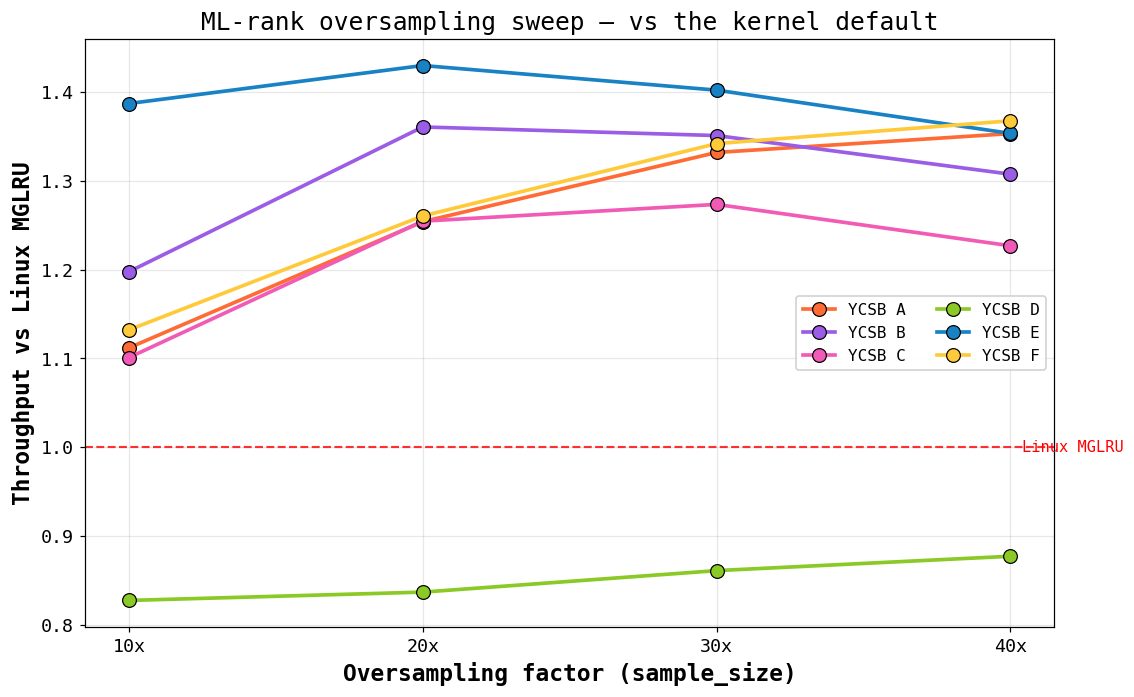

In [6]:
mglru_base = tput['MGLRU (Linux)']

fig, ax = plt.subplots(figsize=(10.5, 6.5))
for w, wl, c in zip(WORKLOADS, WLABELS, wl_colors):
    rel = [tput.loc[w, RANK_LABELS[f]] / mglru_base[w] for f in FACTORS]
    ax.plot(FACTORS, rel, marker='o', markersize=9, linewidth=2.4, color=c,
            markeredgecolor='black', markeredgewidth=0.8, label=wl.replace('\n', ' '))
ax.axhline(1.0, color='red', linestyle='--', linewidth=1.4, alpha=0.8)
ax.text(40.4, 1.0, 'Linux MGLRU', color='red', fontsize=10, va='center')
ax.set_xticks(FACTORS); ax.set_xticklabels([f'{f}x' for f in FACTORS])
ax.set_xlabel('Oversampling factor (sample_size)')
ax.set_ylabel('Throughput vs Linux MGLRU')
ax.set_title('ML-rank oversampling sweep — vs the kernel default')
ax.legend(ncol=2)
fig.tight_layout()
fig.savefig(os.path.join(FIGS, 'fig3c_oversampling_sweep_vs_mglru.png'))
plt.show()

## Normalized-throughput heatmap
Every policy on every workload, normalized to the best classical policy of
that workload (1.00 = matches it; greener = better).

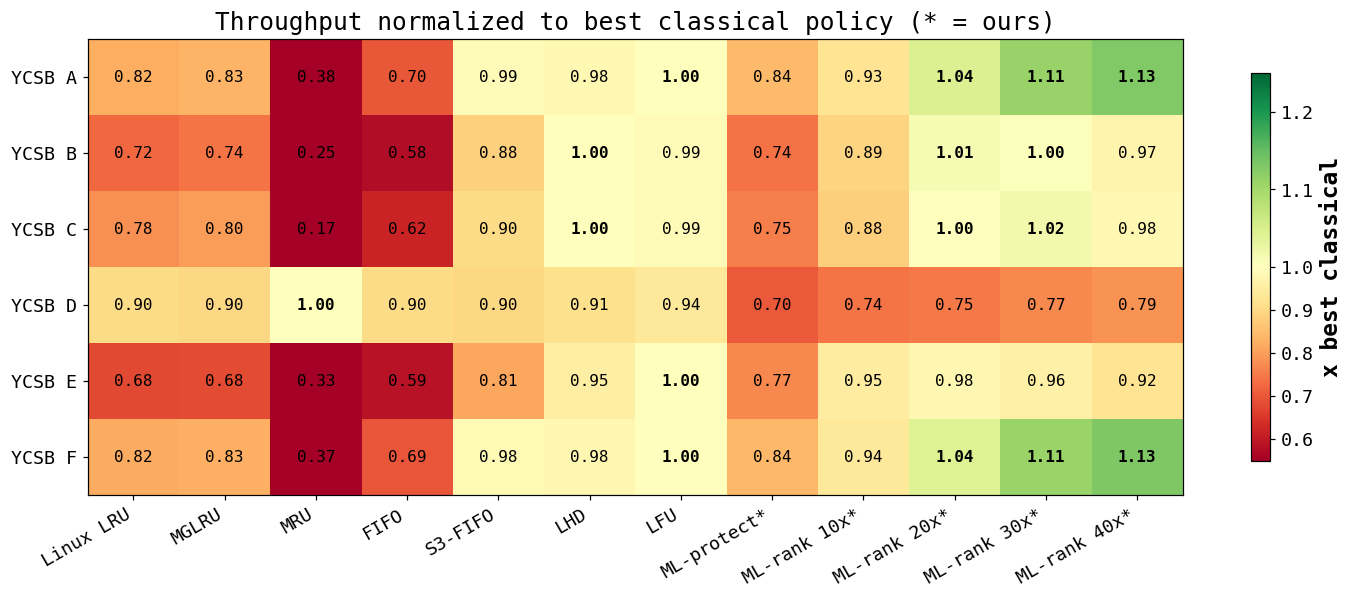

In [7]:
HEAT_POLS = ['Linux LRU', 'MGLRU (Linux)'] + CLASSICAL + ['ML-protect (ours)'] + \
            [RANK_LABELS[f] for f in FACTORS]
norm = (tput[HEAT_POLS].T / best_classical).T

with plt.rc_context({'axes.grid': False}):  # grids would fight imshow + colorbar
    fig, ax = plt.subplots(figsize=(13.5, 5.6))
    im = ax.imshow(norm.values, cmap='RdYlGn',
                   norm=TwoSlopeNorm(vcenter=1.0, vmin=0.55, vmax=1.25),
                   aspect='auto')
    ax.set_xticks(range(len(HEAT_POLS)))
    ax.set_xticklabels([p.replace(' (cache_ext)', '').replace(' (ours)', '*').replace(' (Linux)', '')
                        for p in HEAT_POLS], rotation=30, ha='right')
    ax.set_yticks(range(len(WORKLOADS)))
    ax.set_yticklabels([w.replace('ycsb_', 'YCSB ').upper() for w in WORKLOADS])
    for i in range(norm.shape[0]):
        for j in range(norm.shape[1]):
            v = norm.values[i, j]
            if np.isfinite(v):
                ax.text(j, i, f'{v:.2f}', ha='center', va='center', fontsize=10.5,
                        fontweight='bold' if v >= 1.0 else 'normal')
    ax.set_title('Throughput normalized to best classical policy (* = ours)')
    fig.colorbar(im, ax=ax, shrink=0.85, label='x best classical')
    fig.tight_layout()
    fig.savefig(os.path.join(FIGS, 'fig5_normalized_heatmap.png'))
    plt.show()

### Same heatmap, normalized to FIFO
Value-added view: how much each policy gains (or loses) relative to plain
FIFO — the base both ML variants are built on. Diverging scale centered at
1.0 (= FIFO parity).

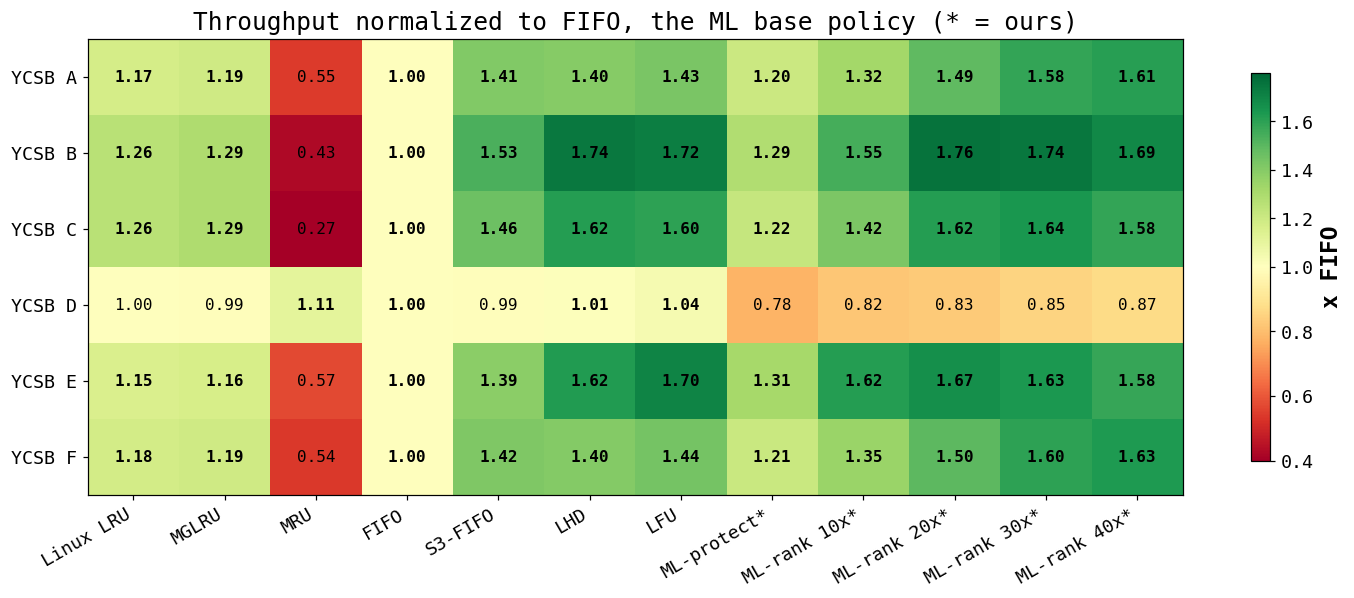

In [8]:
from matplotlib.colors import TwoSlopeNorm

norm_fifo = (tput[HEAT_POLS].T / fifo).T

with plt.rc_context({'axes.grid': False}):
    fig, ax = plt.subplots(figsize=(13.5, 5.6))
    im = ax.imshow(norm_fifo.values, cmap='RdYlGn',
                   norm=TwoSlopeNorm(vcenter=1.0, vmin=0.4, vmax=1.8),
                   aspect='auto')
    ax.set_xticks(range(len(HEAT_POLS)))
    ax.set_xticklabels([p.replace(' (cache_ext)', '').replace(' (ours)', '*').replace(' (Linux)', '')
                        for p in HEAT_POLS], rotation=30, ha='right')
    ax.set_yticks(range(len(WORKLOADS)))
    ax.set_yticklabels([w.replace('ycsb_', 'YCSB ').upper() for w in WORKLOADS])
    for i in range(norm_fifo.shape[0]):
        for j in range(norm_fifo.shape[1]):
            v = norm_fifo.values[i, j]
            if np.isfinite(v):
                ax.text(j, i, f'{v:.2f}', ha='center', va='center', fontsize=10.5,
                        fontweight='bold' if v >= 1.0 else 'normal')
    ax.set_title('Throughput normalized to FIFO, the ML base policy (* = ours)')
    fig.colorbar(im, ax=ax, shrink=0.85, label='x FIFO')
    fig.tight_layout()
    fig.savefig(os.path.join(FIGS, 'fig5b_normalized_heatmap_vs_fifo.png'))
    plt.show()

### Same heatmap, normalized to Linux MGLRU
Deployment view: red cells would lose throughput versus simply running the
stock kernel default.

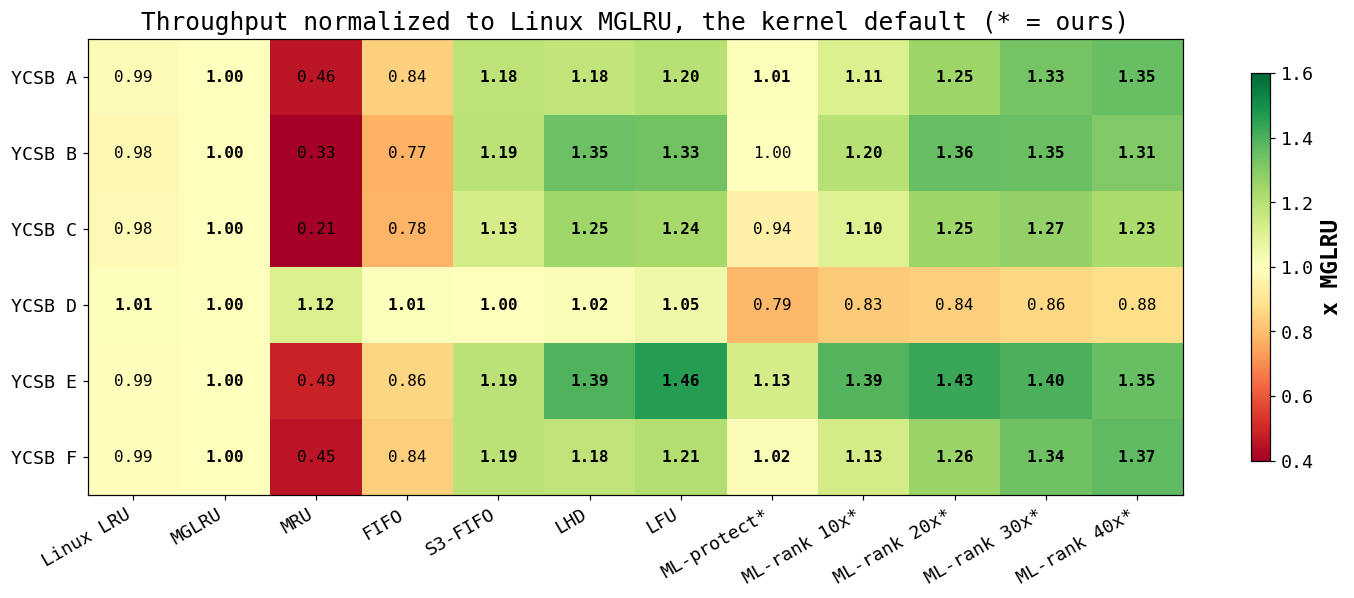

In [9]:
norm_mglru = (tput[HEAT_POLS].T / mglru_base).T

with plt.rc_context({'axes.grid': False}):
    fig, ax = plt.subplots(figsize=(13.5, 5.6))
    im = ax.imshow(norm_mglru.values, cmap='RdYlGn',
                   norm=TwoSlopeNorm(vcenter=1.0, vmin=0.4, vmax=1.6),
                   aspect='auto')
    ax.set_xticks(range(len(HEAT_POLS)))
    ax.set_xticklabels([p.replace(' (cache_ext)', '').replace(' (ours)', '*').replace(' (Linux)', '')
                        for p in HEAT_POLS], rotation=30, ha='right')
    ax.set_yticks(range(len(WORKLOADS)))
    ax.set_yticklabels([w.replace('ycsb_', 'YCSB ').upper() for w in WORKLOADS])
    for i in range(norm_mglru.shape[0]):
        for j in range(norm_mglru.shape[1]):
            v = norm_mglru.values[i, j]
            if np.isfinite(v):
                ax.text(j, i, f'{v:.2f}', ha='center', va='center', fontsize=10.5,
                        fontweight='bold' if v >= 1.0 else 'normal')
    ax.set_title('Throughput normalized to Linux MGLRU, the kernel default (* = ours)')
    fig.colorbar(im, ax=ax, shrink=0.85, label='x MGLRU')
    fig.tight_layout()
    fig.savefig(os.path.join(FIGS, 'fig5c_normalized_heatmap_vs_mglru.png'))
    plt.show()

## Per-operation tail latency
READ vs UPDATE p99 for the key policies (workloads that issue both op types).
Checks that ML-rank's throughput wins aren't bought with one op type's tail.

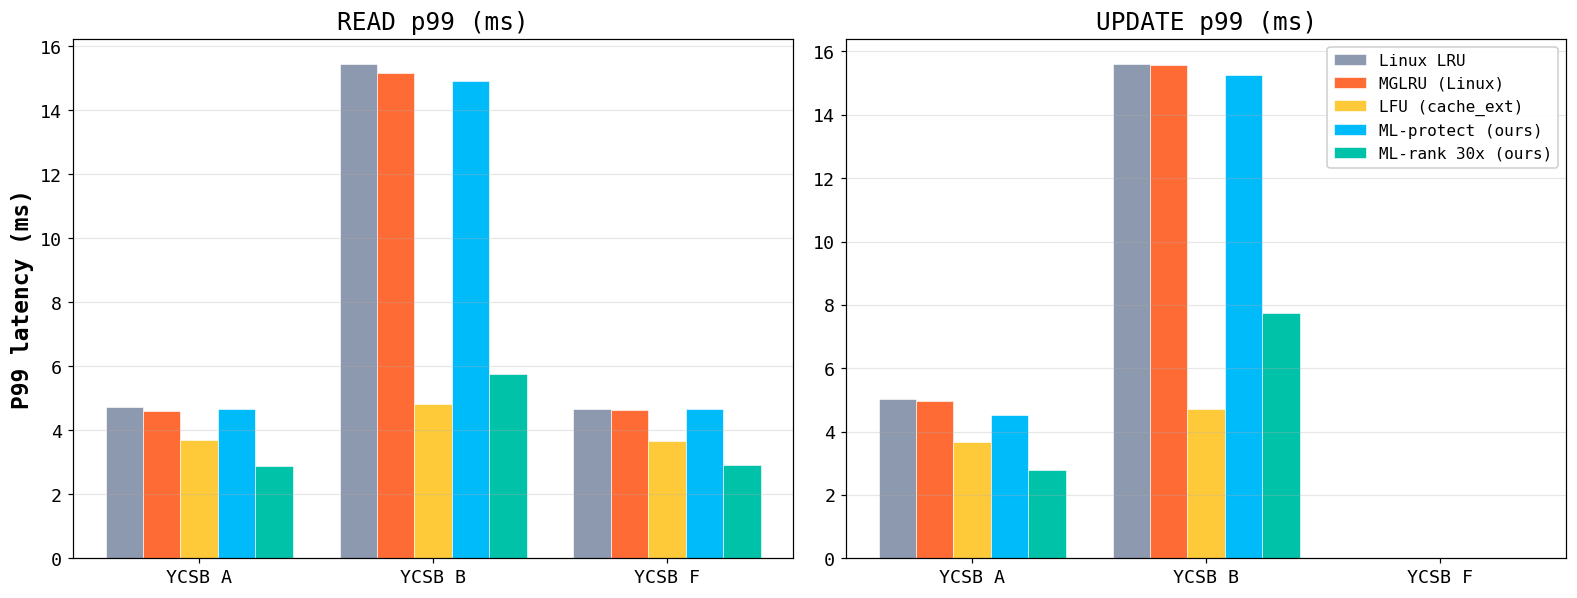

In [10]:
OPS_WORKLOADS = ['ycsb_a', 'ycsb_b', 'ycsb_f']  # update-bearing workloads
OPS_POLS = ['Linux LRU', 'MGLRU (Linux)', 'LFU (cache_ext)', 'ML-protect (ours)', 'ML-rank 30x (ours)']
read_p = df.pivot(index='workload', columns='policy', values='read_p99_ms')
upd_p = df.pivot(index='workload', columns='policy', values='update_p99_ms')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14.5, 5.6), sharey=False)
x = np.arange(len(OPS_WORKLOADS)); width = 0.8 / len(OPS_POLS)
for i, pol in enumerate(OPS_POLS):
    pos = x - 0.4 + width * (i + 0.5)
    ax1.bar(pos, read_p.loc[OPS_WORKLOADS, pol].values, width, label=pol,
            color=COLORS[pol], edgecolor='white', linewidth=0.4)
    ax2.bar(pos, upd_p.loc[OPS_WORKLOADS, pol].values, width, label=pol,
            color=COLORS[pol], edgecolor='white', linewidth=0.4)
ax1.set_title('READ p99 (ms)'); ax2.set_title('UPDATE p99 (ms)')
for ax in (ax1, ax2):
    ax.set_xticks(x)
    ax.set_xticklabels([w.replace('ycsb_', 'YCSB ').upper() for w in OPS_WORKLOADS])
    ax.grid(axis='x', alpha=0)
ax1.set_ylabel('P99 latency (ms)')
ax2.legend()
fig.tight_layout()
fig.savefig(os.path.join(FIGS, 'fig6_per_op_p99.png'))
plt.show()

## Speedup over Linux MGLRU
The deployment question: what do you gain over the stock kernel default?

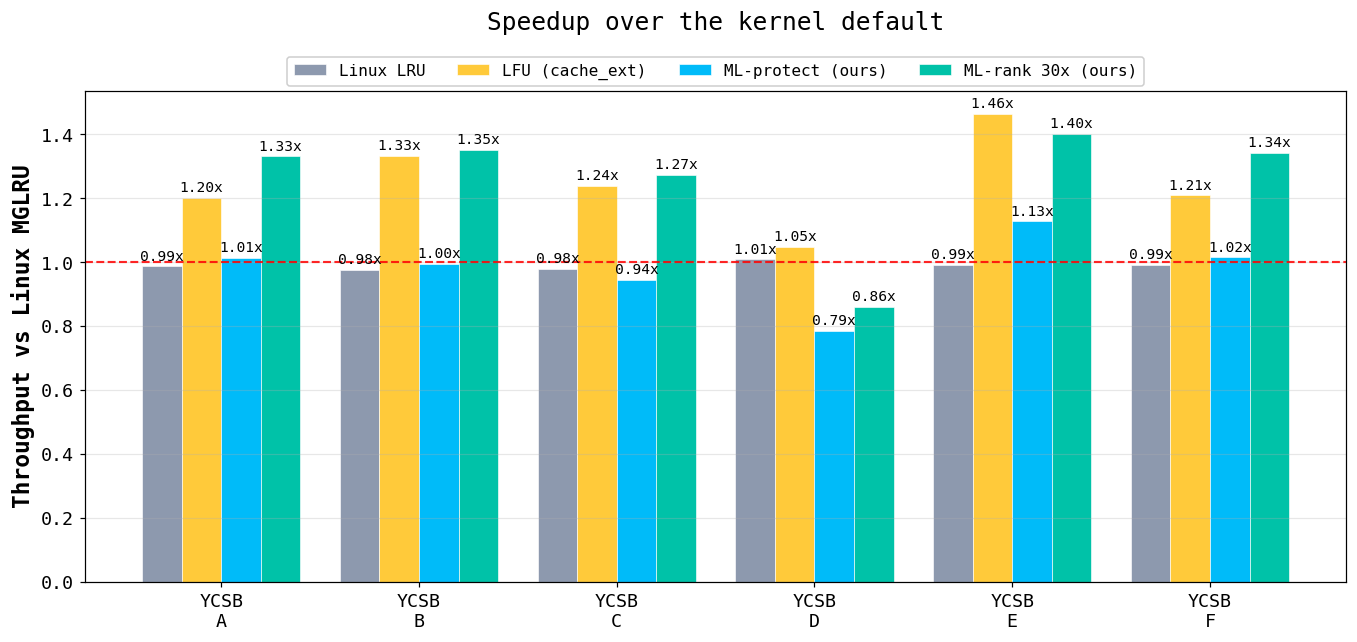

In [11]:
SPEED_POLS = ['Linux LRU', 'LFU (cache_ext)', 'ML-protect (ours)', 'ML-rank 30x (ours)']
mglru = tput['MGLRU (Linux)']

fig, ax = plt.subplots(figsize=(12.5, 6))
x = np.arange(len(WORKLOADS)); width = 0.8 / len(SPEED_POLS)
for i, pol in enumerate(SPEED_POLS):
    pos = x - 0.4 + width * (i + 0.5)
    vals = (tput[pol] / mglru).values
    bars = ax.bar(pos, vals, width, label=pol, color=COLORS[pol],
                  edgecolor='white', linewidth=0.4)
    for r, v in zip(bars, vals):
        ax.annotate(f'{v:.2f}x', (r.get_x() + r.get_width()/2, v),
                    ha='center', va='bottom', fontsize=9.5, rotation=0,
                    xytext=(0, 2), textcoords='offset points')
ax.axhline(1.0, color='red', linestyle='--', linewidth=1.4, alpha=0.85)
ax.set_xticks(x); ax.set_xticklabels(WLABELS)
ax.set_ylabel('Throughput vs Linux MGLRU')
ax.set_title('Speedup over the kernel default', pad=40)
# Legend as a horizontal strip above the axes so it cannot cover any bar label
ax.legend(ncol=4, loc='lower center', bbox_to_anchor=(0.5, 1.0),
          borderaxespad=0.3)
ax.grid(axis='x', alpha=0)
fig.tight_layout()
fig.savefig(os.path.join(FIGS, 'fig7_speedup_vs_mglru.png'))
plt.show()

## Eviction-decision latency
Raw per-call `evict_folios` durations (one `bpf_printk` sample per eviction
batch, captured from trace_pipe during short ycsb_a runs; 100k–255k samples
per policy). Parsed directly from the raw ftrace files
`results/evict_latency/<tag>.trace` (one `bpf_trace_printk: evict_lat_ns=<delta>`
line per `evict_folios` call) — see the loader in the next cell.

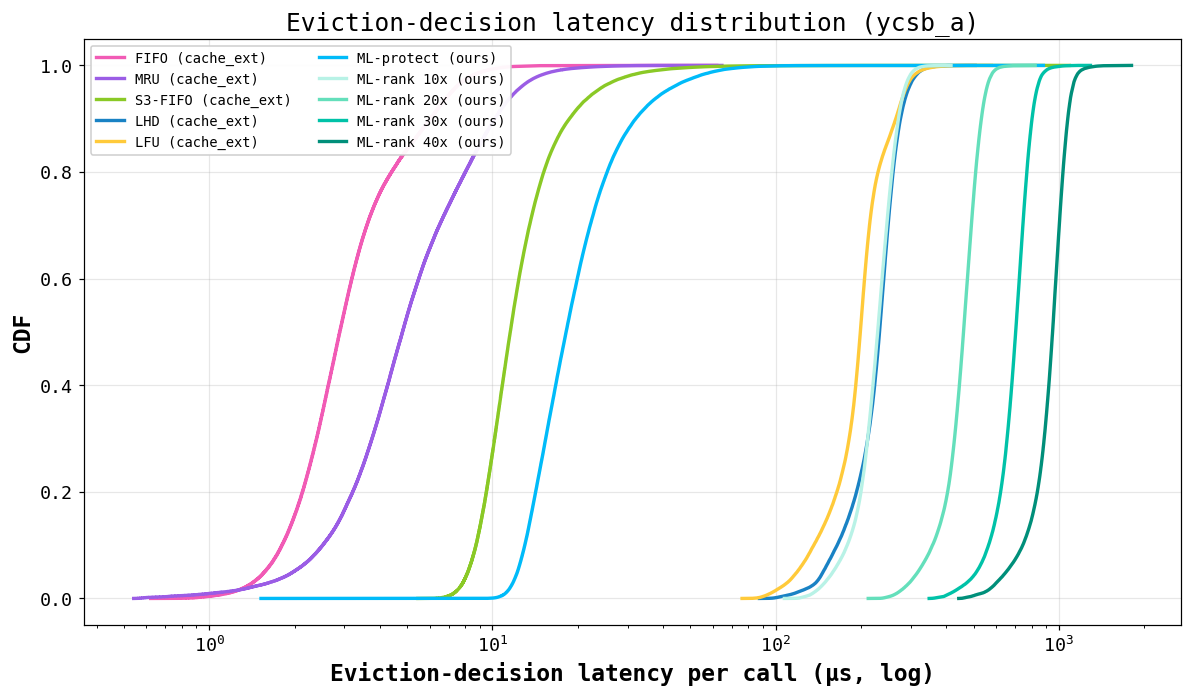

In [12]:
# Load raw per-call samples and plot the latency CDF (log x) per policy.
LAT_DIR = os.path.join(RES, 'evict_latency')
LAT_TAGS = {   # tag -> (label, color)
    'fifo':      ('FIFO (cache_ext)',    COLORS['FIFO (cache_ext)']),
    'mru':       ('MRU (cache_ext)',     COLORS['MRU (cache_ext)']),
    's3fifo':    ('S3-FIFO (cache_ext)', COLORS['S3-FIFO (cache_ext)']),
    'lhd':       ('LHD (cache_ext)',     COLORS['LHD (cache_ext)']),
    'sampling':  ('LFU (cache_ext)',     COLORS['LFU (cache_ext)']),
    'mlprotect': ('ML-protect (ours)',   COLORS['ML-protect (ours)']),
    'ml10':      ('ML-rank 10x (ours)',  COLORS['ML-rank 10x (ours)']),
    'ml20':      ('ML-rank 20x (ours)',  COLORS['ML-rank 20x (ours)']),
    'ml30':      ('ML-rank 30x (ours)',  COLORS['ML-rank 30x (ours)']),
    'ml40':      ('ML-rank 40x (ours)',  COLORS['ML-rank 40x (ours)']),
}
# Parse the raw ftrace .trace files directly (one bpf_printk per
# evict_folios call: "... <ts>: bpf_trace_printk: evict_lat_ns=<delta>").
import re
_LAT_RE = re.compile(r'\s(\d+\.\d+):\s+\S+\s+evict_lat_ns=(\d+)')
def _trace_latency_us(path):
    if not os.path.exists(path):
        return None
    vals = []
    with open(path, errors='replace') as f:
        for line in f:
            m = _LAT_RE.search(line)
            if m:
                vals.append(int(m.group(2)) / 1000.0)
    return np.array(vals) if vals else None

lat_us = {}
for tag in LAT_TAGS:
    arr = _trace_latency_us(os.path.join(LAT_DIR, f'{tag}.trace'))
    if arr is not None:
        lat_us[tag] = arr

fig, ax = plt.subplots(figsize=(11, 6.5))
for tag, (label, color) in LAT_TAGS.items():
    if tag not in lat_us:
        continue
    v = np.sort(lat_us[tag])
    ax.plot(v, np.linspace(0, 1, len(v)), linewidth=2.2, color=color, label=label)
ax.set_xscale('log')
ax.set_xlabel('Eviction-decision latency per call (µs, log)')
ax.set_ylabel('CDF')
ax.set_title('Eviction-decision latency distribution (ycsb_a)')
ax.legend(fontsize=9, ncol=2, loc='upper left')
fig.tight_layout()
fig.savefig(os.path.join(FIGS, 'fig8_evict_latency_cdf.png'))
plt.show()

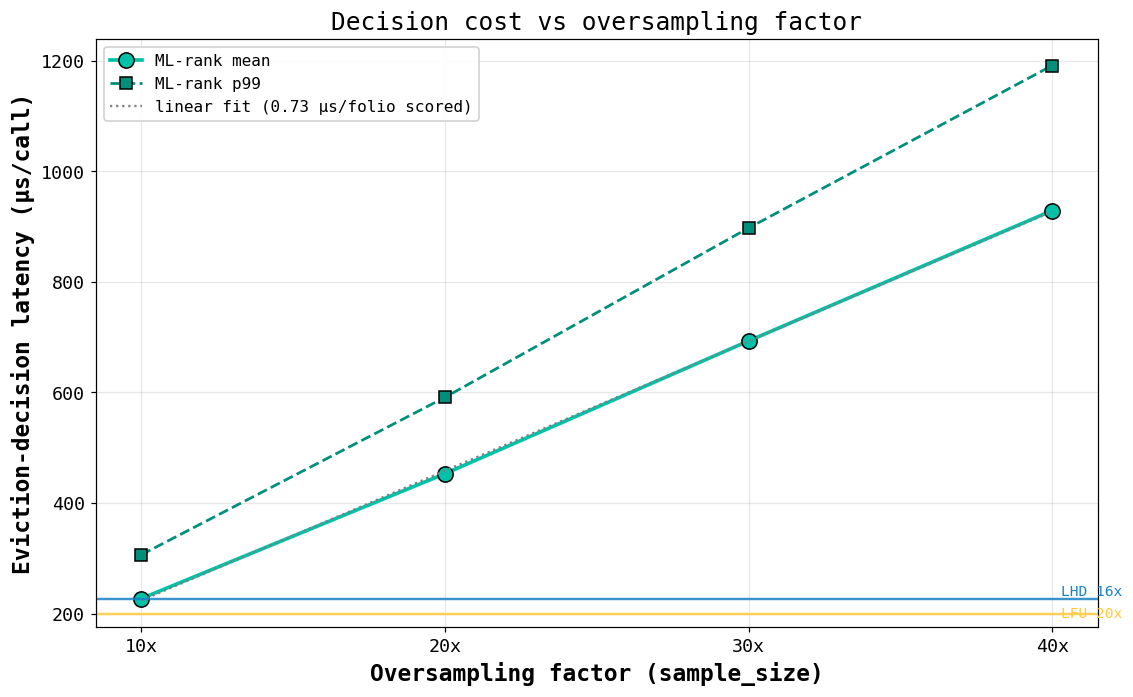

In [13]:
# ML-rank cost scales linearly with the oversampling factor (~0.7 µs per
# scored folio: factor x 32 victims folios per call). LFU/LHD shown as
# same-machinery reference lines.
factors = np.array(FACTORS)
means = np.array([np.mean(lat_us[f'ml{f}']) for f in factors])
p99s = np.array([np.percentile(lat_us[f'ml{f}'], 99) for f in factors])
slope, intercept = np.polyfit(factors, means, 1)
per_folio_us = slope / 32  # 32-victim batches

fig, ax = plt.subplots(figsize=(10.5, 6.5))
ax.plot(factors, means, marker='o', markersize=10, linewidth=2.4,
        color='#00C2A8', markeredgecolor='black', label='ML-rank mean')
ax.plot(factors, p99s, marker='s', markersize=8, linewidth=1.8,
        linestyle='--', color='#008F7A', markeredgecolor='black',
        label='ML-rank p99')
ax.plot(factors, slope * factors + intercept, linestyle=':', color='gray',
        linewidth=1.5, label=f'linear fit ({per_folio_us:.2f} µs/folio scored)')
for ref, color in (('sampling', COLORS['LFU (cache_ext)']),
                   ('lhd', COLORS['LHD (cache_ext)'])):
    ax.axhline(np.mean(lat_us[ref]), color=color, linewidth=1.6, alpha=0.85)
ax.text(40.3, np.mean(lat_us['sampling']), 'LFU 20x', fontsize=9.5,
        va='center', color=COLORS['LFU (cache_ext)'])
ax.text(40.3, np.mean(lat_us['lhd']), 'LHD 16x', fontsize=9.5,
        va='bottom', color=COLORS['LHD (cache_ext)'])
ax.set_xticks(factors); ax.set_xticklabels([f'{f}x' for f in factors])
ax.set_xlabel('Oversampling factor (sample_size)')
ax.set_ylabel('Eviction-decision latency (µs/call)')
ax.set_title('Decision cost vs oversampling factor')
ax.legend()
fig.tight_layout()
fig.savefig(os.path.join(FIGS, 'fig9_evict_latency_scaling.png'))
plt.show()

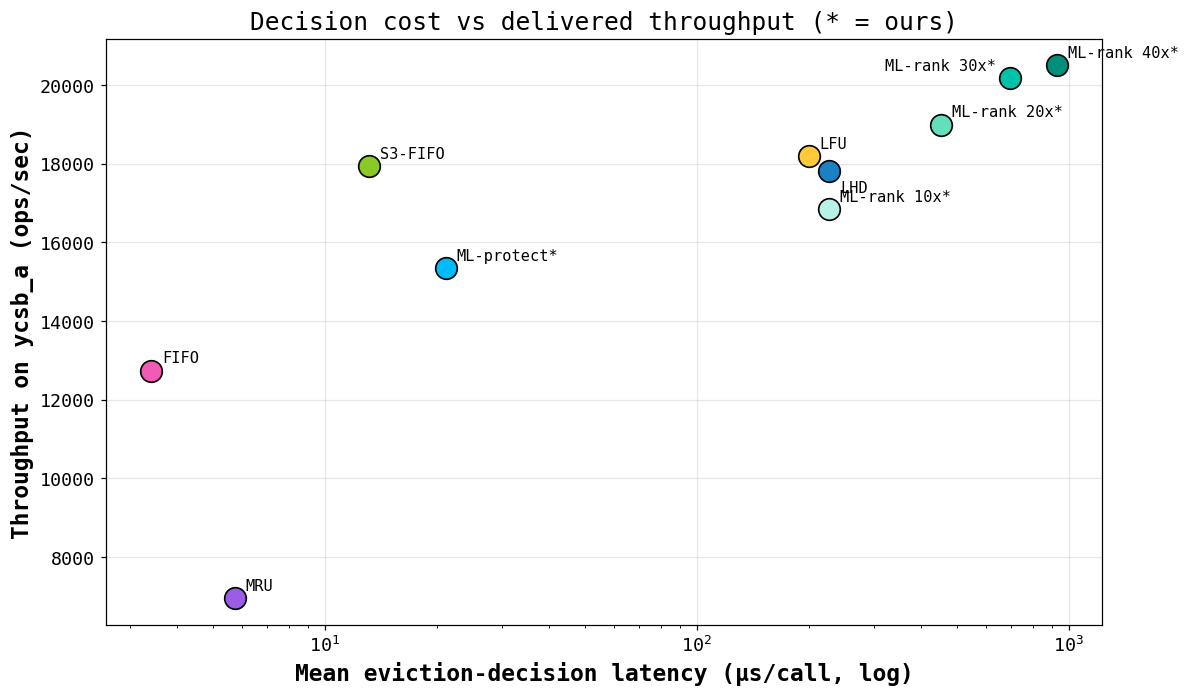

In [14]:
# Decision cost vs delivered throughput (ycsb_a): what the precision buys.
PAIR = {  # tag -> throughput column label
    'mru': 'MRU (cache_ext)', 'fifo': 'FIFO (cache_ext)',
    's3fifo': 'S3-FIFO (cache_ext)', 'lhd': 'LHD (cache_ext)',
    'sampling': 'LFU (cache_ext)', 'mlprotect': 'ML-protect (ours)',
    'ml10': 'ML-rank 10x (ours)', 'ml20': 'ML-rank 20x (ours)',
    'ml30': 'ML-rank 30x (ours)', 'ml40': 'ML-rank 40x (ours)',
}
# (dx, dy, ha) per tag; ml30's label would otherwise run under the 40x dot
LABEL_POS = {'ml30': (-9, 5, 'right'), 'lhd': (7, -14, 'left')}

fig, ax = plt.subplots(figsize=(11, 6.5))
for tag, col in PAIR.items():
    if tag not in lat_us or col not in tput.columns:
        continue
    x = np.mean(lat_us[tag])
    y = tput.loc['ycsb_a', col]
    ax.scatter(x, y, s=200, color=COLORS[col], edgecolor='black',
               linewidth=1.1, zorder=3)
    dx, dy, ha = LABEL_POS.get(tag, (7, 5, 'left'))
    ax.annotate(col.replace(' (cache_ext)', '').replace(' (ours)', '*'),
                (x, y), xytext=(dx, dy), textcoords='offset points',
                ha=ha, fontsize=10)
ax.set_xscale('log')
ax.set_xlabel('Mean eviction-decision latency (µs/call, log)')
ax.set_ylabel('Throughput on ycsb_a (ops/sec)')
ax.set_title('Decision cost vs delivered throughput (* = ours)')
fig.tight_layout()
fig.savefig(os.path.join(FIGS, 'fig10_cost_vs_throughput.png'))
plt.show()

## Twitter cluster benchmark results

Production Twitter cache traces (paper Fig 8), clusters 17/18/24/34/52, replayed
against per-cluster LevelDB DBs. **Throughput-only** — the `leveldb-latency`
My-YCSB branch disables per-op latency, so only the throughput / speedup /
normalized views below apply (there is no p99 panel).

Populate `results/twitter_eval_*.json` with `lc-eval/twitter/reproduce_eval.sh`
(needs per-cluster models). Until then the cells below print a notice and skip.

In [15]:
# --- Twitter results -> tidy DataFrame (mirrors the ycsb loader) ---
TWITTER_CLUSTERS = [17, 18, 24, 34, 52]
TWITTER_WL = [f'twitter_cluster{c}_bench' for c in TWITTER_CLUSTERS]
TWITTER_WLABELS = [f'C{c}' for c in TWITTER_CLUSTERS]

def twitter_rows_from(path, ml_label=None, baseline_label='MGLRU (Linux)'):
    if not os.path.exists(path):
        return []
    out = []
    for e in json.load(open(path)):
        cfg, res = e['config'], e['results']
        w = cfg.get('benchmark')
        if w not in TWITTER_WL:
            continue
        if cfg.get('cgroup_name') == 'baseline_test':
            label = baseline_label
        else:
            loader = cfg.get('policy_loader')
            label = (ml_label if loader == 'cache_ext_ml_sampling.out'
                     else LOADER_LABEL.get(loader))
        if not label:
            continue
        out.append({'workload': w, 'policy': label, 'tput': res.get('throughput_avg')})
    return out

tdf = pd.DataFrame(
    twitter_rows_from(os.path.join(RES, 'twitter_eval_results.json'))
    + twitter_rows_from(os.path.join(RES, 'twitter_eval_lru.json'), baseline_label='Linux LRU')
    + twitter_rows_from(os.path.join(RES, 'twitter_eval_mglru.json'))
    + twitter_rows_from(os.path.join(RES, 'twitter_eval_ml10.json'), 'ML-rank 10x (ours)')
    + twitter_rows_from(os.path.join(RES, 'twitter_eval_ml20.json'), 'ML-rank 20x (ours)')
    + twitter_rows_from(os.path.join(RES, 'twitter_eval_ml30.json'), 'ML-rank 30x (ours)')
    + twitter_rows_from(os.path.join(RES, 'twitter_eval_ml40.json'), 'ML-rank 40x (ours)'))

TWITTER_OK = not tdf.empty
if not TWITTER_OK:
    ttput = None
    print('No Twitter results yet - run lc-eval/twitter/reproduce_eval.sh to populate '
          'results/twitter_eval_*.json, then re-run this notebook.')
else:
    # average across iterations (run_model_eval defaults to 3) -> one value per (cluster, policy)
    ttput = (tdf.groupby(['workload', 'policy'])['tput'].mean()
                .unstack('policy').reindex(TWITTER_WL))
    print(f'{len(tdf)} rows, {tdf.policy.nunique()} policies x {tdf.workload.nunique()} clusters')
    display(ttput.round(0))

No Twitter results yet - run lc-eval/twitter/reproduce_eval.sh to populate results/twitter_eval_*.json, then re-run this notebook.


In [16]:
# Twitter per-cluster throughput bars (throughput-only; no p99 panel)
if not TWITTER_OK:
    print('No Twitter results - skipping throughput figure.')
else:
    TW_HEADLINE = ['Linux LRU', 'MGLRU (Linux)', 'MRU (cache_ext)', 'FIFO (cache_ext)',
                   'S3-FIFO (cache_ext)', 'LHD (cache_ext)', 'LFU (cache_ext)',
                   'ML-protect (ours)', 'ML-rank 30x (ours)']
    pols = [p for p in TW_HEADLINE if p in ttput.columns]
    fig, ax = plt.subplots(figsize=(13.5, 6))
    x = np.arange(len(TWITTER_WL)); width = 0.8 / max(len(pols), 1)
    for i, pol in enumerate(pols):
        pos = x - 0.4 + width * (i + 0.5)
        vals = ttput[pol].reindex(TWITTER_WL).values
        bars = ax.bar(pos, vals, width, label=pol, color=COLORS.get(pol),
                      edgecolor='white', linewidth=0.4)
        for r, v in zip(bars, vals):
            if np.isfinite(v) and v > 0:
                ax.annotate(f'{v/1000:.1f}K' if v >= 1000 else f'{v:.0f}',
                            (r.get_x() + r.get_width()/2, v), ha='center', va='bottom',
                            fontsize=7, rotation=90, color=COLORS.get(pol),
                            fontweight='bold', xytext=(0, 2), textcoords='offset points')
    ax.set_ylabel('Throughput (ops/sec)')
    ax.set_xticks(x); ax.set_xticklabels(TWITTER_WLABELS)
    ax.set_title('Twitter cluster throughput by policy')
    ax.legend(ncol=3, loc='lower center', bbox_to_anchor=(0.5, 1.0), borderaxespad=0.3)
    ax.grid(axis='x', alpha=0)
    fig.tight_layout()
    fig.savefig(os.path.join(FIGS, 'fig11_twitter_throughput.png'))
    plt.show()

No Twitter results - skipping throughput figure.


In [17]:
# Twitter speedup over Linux MGLRU (ratio is comparable across clusters)
if not TWITTER_OK:
    print('No Twitter results - skipping speedup figure.')
elif 'MGLRU (Linux)' not in ttput.columns:
    print('No MGLRU baseline rows - skipping speedup figure.')
else:
    SPEED_POLS = [p for p in ['Linux LRU', 'LFU (cache_ext)', 'ML-protect (ours)', 'ML-rank 30x (ours)']
                  if p in ttput.columns]
    mglru = ttput['MGLRU (Linux)'].reindex(TWITTER_WL)
    fig, ax = plt.subplots(figsize=(12.5, 6))
    x = np.arange(len(TWITTER_WL)); width = 0.8 / max(len(SPEED_POLS), 1)
    for i, pol in enumerate(SPEED_POLS):
        pos = x - 0.4 + width * (i + 0.5)
        vals = (ttput[pol].reindex(TWITTER_WL) / mglru).values
        bars = ax.bar(pos, vals, width, label=pol, color=COLORS.get(pol),
                      edgecolor='white', linewidth=0.4)
        for r, v in zip(bars, vals):
            if np.isfinite(v):
                ax.annotate(f'{v:.2f}x', (r.get_x() + r.get_width()/2, v), ha='center',
                            va='bottom', fontsize=9, xytext=(0, 2), textcoords='offset points')
    ax.axhline(1.0, color='red', linestyle='--', linewidth=1.4, alpha=0.85)
    ax.set_xticks(x); ax.set_xticklabels(TWITTER_WLABELS)
    ax.set_ylabel('Throughput vs Linux MGLRU')
    ax.set_title('Twitter: speedup over the kernel default', pad=40)
    ax.legend(ncol=4, loc='lower center', bbox_to_anchor=(0.5, 1.0), borderaxespad=0.3)
    ax.grid(axis='x', alpha=0)
    fig.tight_layout()
    fig.savefig(os.path.join(FIGS, 'fig11b_twitter_speedup_vs_mglru.png'))
    plt.show()

No Twitter results - skipping speedup figure.


In [18]:
# Twitter throughput heatmap, normalized to Linux MGLRU
if not TWITTER_OK:
    print('No Twitter results - skipping heatmap.')
elif 'MGLRU (Linux)' not in ttput.columns:
    print('No MGLRU baseline rows - skipping heatmap.')
else:
    HEAT_POLS = [p for p in (['Linux LRU', 'MGLRU (Linux)'] + CLASSICAL + ['ML-protect (ours)']
                 + [f'ML-rank {f}x (ours)' for f in (10, 20, 30, 40)]) if p in ttput.columns]
    base = ttput['MGLRU (Linux)'].reindex(TWITTER_WL)
    norm = (ttput[HEAT_POLS].reindex(TWITTER_WL).T / base).T
    with plt.rc_context({'axes.grid': False}):
        fig, ax = plt.subplots(figsize=(13.5, 5.0))
        im = ax.imshow(norm.values, cmap='RdYlGn',
                       norm=TwoSlopeNorm(vcenter=1.0, vmin=0.55, vmax=1.45), aspect='auto')
        ax.set_xticks(range(len(HEAT_POLS)))
        ax.set_xticklabels([p.replace(' (cache_ext)', '').replace(' (ours)', '*').replace(' (Linux)', '')
                            for p in HEAT_POLS], rotation=30, ha='right')
        ax.set_yticks(range(len(TWITTER_WL)))
        ax.set_yticklabels(TWITTER_WLABELS)
        for i in range(norm.shape[0]):
            for j in range(norm.shape[1]):
                v = norm.values[i, j]
                if np.isfinite(v):
                    ax.text(j, i, f'{v:.2f}', ha='center', va='center', fontsize=10,
                            fontweight='bold' if v >= 1.0 else 'normal')
        ax.set_title('Twitter throughput normalized to Linux MGLRU (* = ours)')
        fig.colorbar(im, ax=ax, shrink=0.85, label='x Linux MGLRU')
        fig.tight_layout()
        fig.savefig(os.path.join(FIGS, 'fig11c_twitter_norm_heatmap.png'))
        plt.show()

No Twitter results - skipping heatmap.
